# Adding molecule level descriptor to MPNN model

In [1]:
# import necessary libraries
import sys
from pathlib import Path

import numpy as np
import pandas as pd

from lightning import pytorch as pl

from chemprop import data, featurizers, models, nn, utils
from chemprop.models.utils import save_model

Setting up local imports of custom python functions

In [2]:
# Ensure project root is on path (one level up from 'development')
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Also add the shared directory so that `utils` package can be resolved (matches streamlit_app logic)
SHARED_DIR = PROJECT_ROOT / 'shared'
print(f"Project root: {PROJECT_ROOT}")

Project root: /home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor


In [3]:
from src.base_uilts import get_performance_metrics, plot_xy_trend

In [4]:
from src.chemprop_utils import compute_descriptors

# Reading data
First we read data for SMILES notation and corresponding log(Tg) value for all 902 polymers

In [5]:
input_data_path = PROJECT_ROOT / 'data' / 'processed' / 'Tg_vs_SMILES_all.csv'
df_input = pd.read_csv(input_data_path)
print("Data-frame shape", df_input.shape)
df_input.head()

Data-frame shape (902, 11)


,Unnamed: 0,ID,logTg,Series,Ref,name_raw,SMILES_raw,SMI_generator,SMILES,name,SMILES_clean
0,0,PPD_007,2.7077,T,A,chloroprene,C=CC(=C)Cl,PubChemPy,C=CC(=C)Cl,chloroprene,C=CC(=C)Cl
1,1,PPD_008,2.8520,T,A,acrylamide,C=CC(=O)N,PubChemPy,C=CC(=O)N,acrylamide,C=CC(N)=O
2,2,PPD_010,2.8177,T,A,2-cyanobutyl acrylate,CCC(COC(=O)C=C)C#N,ChemAxon,CCC(COC(=O)C=C)C#N,2-cyanobutyl acrylate,C=CC(=O)OCC(C#N)CC
3,3,PPD_013,2.7178,P,A,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(C(F)F)(F)F,PubChemPy,C=CC(=O)OCC(C(F)F)(F)F,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(F)(F)C(F)F
4,4,PPD_019,2.7552,T,A,cyanomethyl acrylate,C=CC(=O)OCC#N,PubChemPy,C=CC(=O)OCC#N,cyanomethyl acrylate,C=CC(=O)OCC#N


In [6]:
smiles_column = 'SMILES_clean' # column with SMILES notation strings
target_column = ['logTg'] # column with target variable value

## Adding physics-based descriptors
* Free volume proxy (using van der Waals volume)
* Chain flexibility (number of rotatable bonds)
* Aromatic content (number of aromatic rings)
* Polarity (TPSA / dipole moment proxy)
* Hydrogen bond donor/acceptor count
* Molecular weight (exact or monomer-based)

I created a custom function that use RDKit on the backend to create the above-described features.

In [7]:
? compute_descriptors

Signature:  compute_descriptors(smiles)
Docstring:
Compute molecular descriptors for a given SMILES string.

Args:
    smiles (str): The SMILES representation of the molecule.

Returns:
    descriptors (dict): A dictionary containing the computed molecular descriptors.
        keys include:
            - 'MW': Molecular Weight. 
            - 'FreeVolumeProxy': Proxy for free volume.
            - 'RotatableBonds': Number of Rotatable Bonds.
            - 'AromaticRings': Number of Aromatic Rings.
            - 'TPSA': Topological Polar Surface Area.
            - 'HBondDonors': Number of Hydrogen Bond Donors.
            - 'HBondAcceptors': Number of Hydrogen Bond Acceptors
File:      ~/projects/Polymer-Glass-Transition-Temperature-Predictor/src/chemprop_utils.py
Type:      function

In [8]:
# data-frame with molecule-level descriptor data
descriptors_df = pd.DataFrame(
    list(df_input[smiles_column].apply(compute_descriptors))
)
print("Descriptors data-frame shape", descriptors_df.shape)
descriptors_df.head()

Descriptors data-frame shape (902, 7)


,MW,FreeVolumeProxy,RotatableBonds,AromaticRings,TPSA,HBondDonors,HBondAcceptors
0,88.537,17.601596,1,0,0.00,0,0
1,71.079,14.207423,1,0,43.09,1,1
2,153.181,13.916271,4,0,50.09,0,3
3,186.104,15.502533,4,0,26.30,0,2
4,111.100,13.879004,2,0,50.09,0,3


In [9]:
n_descriptors = descriptors_df.shape[1]
print("Number of descriptors per polymer:", n_descriptors)

Number of descriptors per polymer: 7


In [10]:
descriptor_list = descriptors_df.columns.tolist()
descriptor_list

['MW',
 'FreeVolumeProxy',
 'RotatableBonds',
 'AromaticRings',
 'TPSA',
 'HBondDonors',
 'HBondAcceptors']

adding descriptors data-frame to the one containing SMILES notation and log(Tg) values

In [11]:
df_input_w_features = pd.concat(
    [df_input, descriptors_df],
    axis=1
)
print("Final data-frame shape containing all data", df_input_w_features.shape)
df_input_w_features.head()

Final data-frame shape containing all data (902, 18)


,Unnamed: 0,ID,logTg,Series,Ref,name_raw,SMILES_raw,SMI_generator,SMILES,name,SMILES_clean,MW,FreeVolumeProxy,RotatableBonds,AromaticRings,TPSA,HBondDonors,HBondAcceptors
0,0,PPD_007,2.7077,T,A,chloroprene,C=CC(=C)Cl,PubChemPy,C=CC(=C)Cl,chloroprene,C=CC(=C)Cl,88.537,17.601596,1,0,0.00,0,0
1,1,PPD_008,2.8520,T,A,acrylamide,C=CC(=O)N,PubChemPy,C=CC(=O)N,acrylamide,C=CC(N)=O,71.079,14.207423,1,0,43.09,1,1
2,2,PPD_010,2.8177,T,A,2-cyanobutyl acrylate,CCC(COC(=O)C=C)C#N,ChemAxon,CCC(COC(=O)C=C)C#N,2-cyanobutyl acrylate,C=CC(=O)OCC(C#N)CC,153.181,13.916271,4,0,50.09,0,3
3,3,PPD_013,2.7178,P,A,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(C(F)F)(F)F,PubChemPy,C=CC(=O)OCC(C(F)F)(F)F,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(F)(F)C(F)F,186.104,15.502533,4,0,26.30,0,2
4,4,PPD_019,2.7552,T,A,cyanomethyl acrylate,C=CC(=O)OCC#N,PubChemPy,C=CC(=O)OCC#N,cyanomethyl acrylate,C=CC(=O)OCC#N,111.100,13.879004,2,0,50.09,0,3


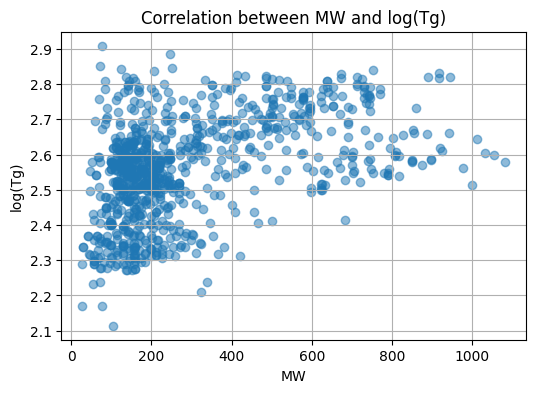

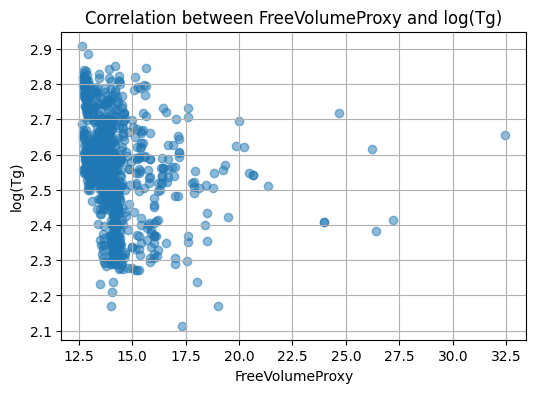

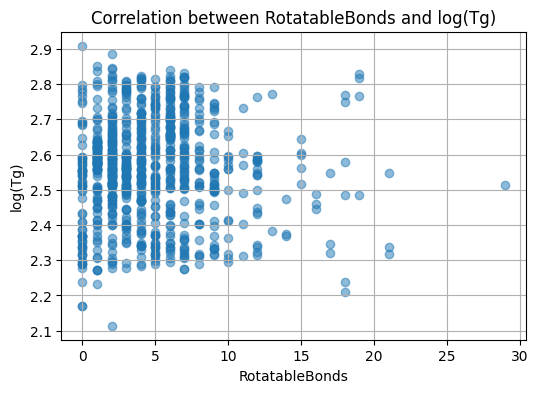

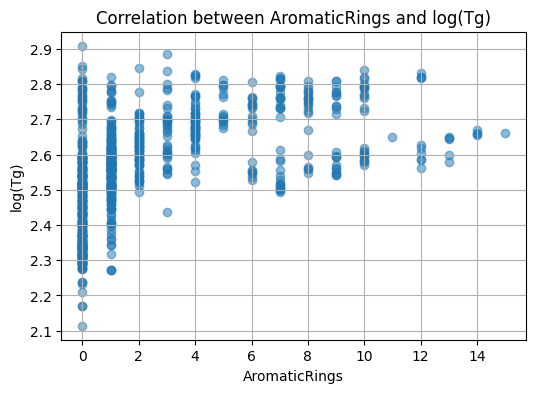

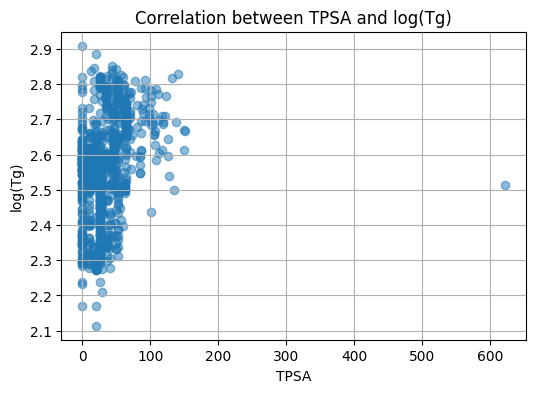

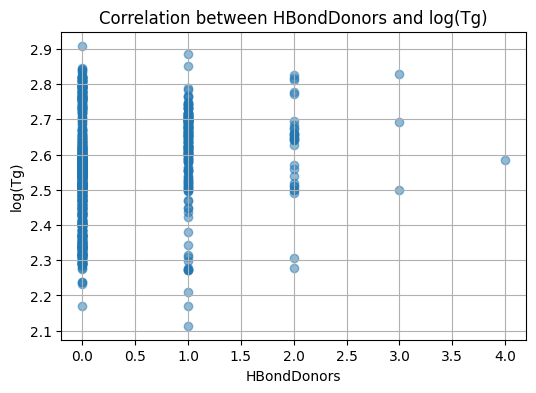

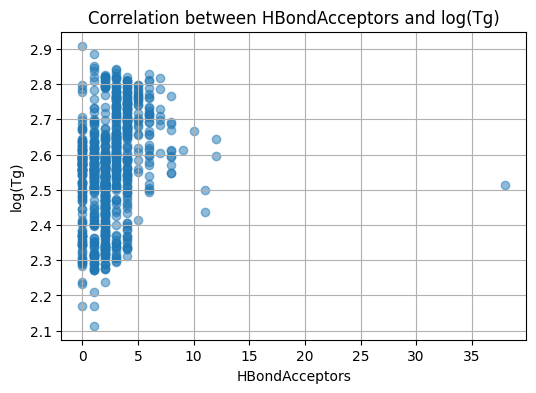

In [12]:
for feat_ in descriptor_list:
    plot_xy_trend(
        x=df_input_w_features[feat_],
        y=df_input_w_features[target_column],
        x_label_=feat_,
        y_label_="log(Tg)",
        title_=f"Correlation between {feat_} and log(Tg)"
    )

# Prepping training data
Now we prepare data-set to be provided to neural network for model training

In [13]:
# get data-frame with training data IDs
train_df = pd.read_csv(
    PROJECT_ROOT / 'data' / 'raw' / 'data_902_original_15desc_logTg_train.csv'
)

# filter input table with IDs within training set
df_smiles_train = df_input_w_features[
    df_input_w_features['ID'].isin(train_df['Index'])
].reset_index(drop=True)

print("Training data-frame w/ SMILES notation", df_smiles_train.shape)

Training data-frame w/ SMILES notation (683, 18)


In [14]:
# converting input data to numpy array for downstream processing
train_smis = df_smiles_train.loc[:, smiles_column].values
print("Input smiles array shape", train_smis.shape)
print(train_smis[:5])

Input smiles array shape (683,)
['C=CC(=C)Cl' 'C=CC(N)=O' 'C=CC(=O)OCC(C#N)CC' 'C=CC(=O)OCC#N'
 'C=CC(=O)OCCCCCCCCCCCCCCCCCC']


In [15]:
# converting target data to numpy array
train_ys = df_smiles_train.loc[:, target_column].values
print("Target value array shape", train_ys.shape)
train_ys[:5]

Target value array shape (683, 1)


array([[2.7077],
       [2.852 ],
       [2.8177],
       [2.7552],
       [2.7687]])

In [16]:
# converting additional descriptors data to numpy array
train_V_fs = df_smiles_train.loc[:, descriptor_list].values
train_V_fs.shape

(683, 7)

For adding molecule-level descriptors, each datapoint is converted to molecule from smiles notation

In [17]:
train_mols = [
    utils.make_mol(smi, keep_h=False, add_h=False) for smi in train_smis
]

In [18]:
# MoleculeDatapoints are made from target value(s) SMILES and additional descriptors. 
train_data = [
    data.MoleculeDatapoint(mol, y, x_d=X_d) for mol, y, X_d in zip(train_mols, train_ys, train_V_fs)
]

# featurizer to transforms molecules into molecular graphs where atoms become nodes and bonds become edges
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()

# define dataset of molecules and it's features
train_dset = data.MoleculeDataset(train_data, featurizer)

# normalizing target variable values for better model fit
scaler = train_dset.normalize_targets()

# define a data loader to be passed to the neural network
train_loader = data.build_dataloader(
    train_dset, # training dataset of molecules
    batch_size=64, # count of data-points to use in each training iteration
    num_workers=20 # number of workers for multi-processing
)

# Message-Passing Neural Network (MPNN)

In [19]:
# construct molecular graph using message passing to learn bond-level hidden representations
mp = nn.BondMessagePassing()

In [20]:
print("Output number of dimensions from Bond-message passing network", mp.output_dim)

Output number of dimensions from Bond-message passing network 300


In [21]:
agg = nn.MeanAggregation()

batch_norm = True

Feed-forward regression network with additional 7 dimensions as input so total of 307

In [22]:
# transform that can be used to unscale model outputs
output_transform = nn.UnscaleTransform.from_standard_scaler(scaler)

# total dimensions of the features then passed to FFN 
ffn_input_dim = mp.output_dim + train_V_fs.shape[1]


ffn = nn.RegressionFFN(
    input_dim=ffn_input_dim,
    output_transform=output_transform,
)
print('FFN created with input_dim =', ffn.input_dim)

FFN created with input_dim = 307


Extra-descriptors are added to the model as normalized scalers

In [23]:
extra_datapoint_descriptors_scaler = train_dset.normalize_inputs("X_d")
X_d_transform = nn.ScaleTransform.from_standard_scaler(extra_datapoint_descriptors_scaler)

Finally putting all pieces together to define a MPNN model.

In [24]:
mpnn = models.MPNN(
    mp, agg, ffn, batch_norm, X_d_transform=X_d_transform
)
mpnn

MPNN(
  (message_passing): BondMessagePassing(
    (W_i): Linear(in_features=86, out_features=300, bias=False)
    (W_h): Linear(in_features=300, out_features=300, bias=False)
    (W_o): Linear(in_features=372, out_features=300, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
    (tau): ReLU()
    (V_d_transform): Identity()
    (graph_transform): Identity()
  )
  (agg): MeanAggregation()
  (bn): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (predictor): RegressionFFN(
    (ffn): MLP(
      (0): Sequential(
        (0): Linear(in_features=307, out_features=300, bias=True)
      )
      (1): Sequential(
        (0): ReLU()
        (1): Dropout(p=0.0, inplace=False)
        (2): Linear(in_features=300, out_features=1, bias=True)
      )
    )
    (criterion): MSE(task_weights=[[1.0]])
    (output_transform): UnscaleTransform()
  )
  (X_d_transform): ScaleTransform()
  (metrics): ModuleList(
    (0-1): 2 x MSE(task_weights=[[1.0]])
  )
)

## Trainer a MPNN model
Defining a trainer object to perform model training

In [25]:
trainer = pl.Trainer(
    logger=False,
    enable_checkpointing=False, # Use `True` if you want to save model checkpoints. The checkpoints will be saved in the `checkpoints` folder.
    enable_progress_bar=True,
    accelerator="auto",
    devices=1, # 
    max_epochs=50, # number of epochs to train for
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


run trainer using the defined neural network and training data-loader

In [26]:
trainer.fit(mpnn, train_loader)

/home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA GeForce RTX 5070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.

  | Name            | Type               | Params | Mode 
---------------------------------------------------------------
0 | message_passing | BondMessagePassing | 227 K  | train
1 | agg             | MeanAggregation    | 0      | train
2 | bn              | Batch

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


In [27]:
# training fit metrics
trainer.callback_metrics

{'train_loss': tensor(0.0604),
 'train_loss_step': tensor(0.0256),
 'train_loss_epoch': tensor(0.0604)}

## Model prediction on training data

In [28]:
# create a separate data-loader but now with shuffling disabled so that all data-points are serially loaded without repitition
train_loader_for_preds = data.build_dataloader(train_dset, num_workers=20, shuffle=False) 

In [29]:
# perform model prediction in batch-wise manner
train_preds_batch = trainer.predict(mpnn, train_loader_for_preds)
print("Total batches of data", len(train_preds_batch))
train_preds = np.concatenate(train_preds_batch, axis=0)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

Total batches of data 11


In [30]:
# add a generic code for R2 score and rmse calc.
get_performance_metrics(
    y_true=df_smiles_train[target_column],
    y_pred=train_preds
)

R2-score:: 0.907
Root Mean Squared Error: 0.044


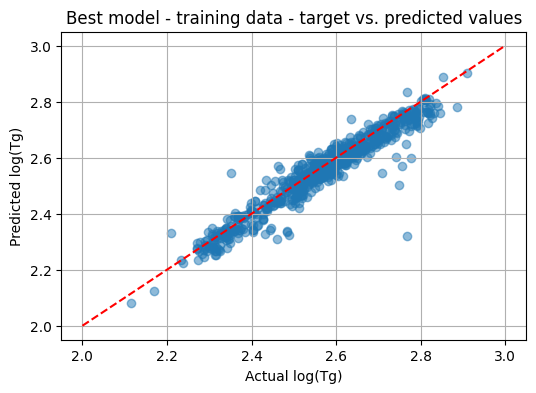

In [31]:
# scatter plot for y_true versus y_pred
plot_xy_trend(
    x=df_smiles_train[target_column],
    y=train_preds,
    x_label_='Actual log(Tg)',
    y_label_='Predicted log(Tg)',
    title_='Best model - training data - target vs. predicted values',
    add_refline=[2, 3]
)

# Validating model on an independent dataset
Using all non-training IDs for testing model prediction

In [35]:
df_smiles_test = df_input_w_features[
    ~df_input_w_features['ID'].isin(train_df['Index'])
].reset_index(drop=True)
df_smiles_test.shape
test_smis = df_smiles_test[smiles_column]
test_smis[:5]

0    C=CC(=O)OCC(F)(F)C(F)F
1               C=CC(C)(C)C
2      C=C(CC(=O)OC)C(=O)OC
3                C=CC(=O)CC
4                    C=CSCC
Name: SMILES_clean, dtype: object

In [36]:
test_mols = [utils.make_mol(smi, keep_h=False, add_h=False) for smi in test_smis]

In [37]:
test_V_fs = df_smiles_test.loc[:, descriptor_list].values
test_V_fs.shape

(219, 7)

In [38]:
test_data = [
    data.MoleculeDatapoint(mol, x_d=X_d) for mol, X_d in zip(test_mols, test_V_fs)
]
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()
test_dset = data.MoleculeDataset(test_data, featurizer)

test_loader = data.build_dataloader(test_dset, shuffle=False)

perform model prediction on test dataset

In [39]:
test_preds = trainer.predict(mpnn, test_loader)
test_preds = np.concatenate(test_preds, axis=0)
test_preds.shape

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

(219, 1)

In [40]:
# add a generic code for R2 score and rmse calc.
get_performance_metrics(
    y_true=df_smiles_test[target_column],
    y_pred=test_preds
)

R2-score:: 0.751
Root Mean Squared Error: 0.069


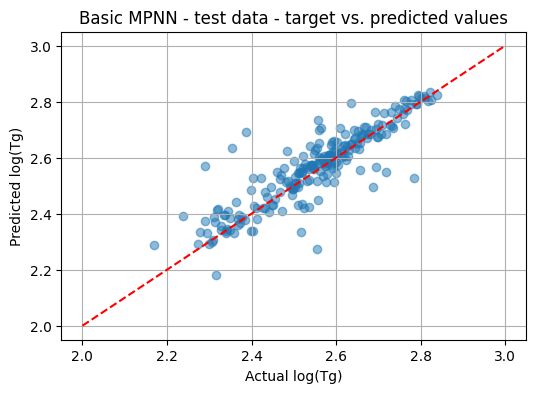

In [41]:
plot_xy_trend(
    x=df_smiles_test[target_column],
    y=test_preds,
    x_label_='Actual log(Tg)',
    y_label_='Predicted log(Tg)',
    title_='Basic MPNN - test data - target vs. predicted values',
    add_refline=[2, 3]
)

# Save the trained model

In [42]:
model_save_path = PROJECT_ROOT / 'data' / 'processed' /'chemprop_w_features_mpnn_model.pickle'
save_model(model_save_path, mpnn)

---